In [12]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [13]:
df = pd.read_csv("../data/processed/preprocessed_data.csv")
df.head()

,Number of followers,Number of following,tfidf_similarity,Number of Activity,Number of Issue,Number of Pull Request,Number of Repository,Number of Commit,Number of Active day,Periodicity of Activities,Number of Connection Account,Median Response Time,label,issue_activity_ratio,pr_activity_ratio,commit_per_repo,follower_following_ratio,activity_per_day
0,1.609438,0.693147,0.019511,10.808246,4.454347,4.043051,4.442651,10.297684,246,0.967936,1.609438,10.100715,0,0.377223,0.342392,1.892034,0.950560,0.043758
1,2.197225,1.945910,0.000000,10.128070,3.091042,2.484907,1.609438,10.126631,339,0.962913,1.386294,7.357237,0,0.277770,0.223301,3.880771,0.745856,0.029788
2,7.089243,5.379897,0.000000,9.421573,3.951244,1.609438,5.111988,9.403602,358,0.961636,1.386294,9.943034,0,0.379141,0.154433,1.538551,1.111185,0.026244
3,4.356709,1.098612,0.002806,10.808246,5.497168,8.795955,6.278521,10.297684,235,0.957628,5.303305,7.662259,1,0.465536,0.744899,1.414804,2.075995,0.045798
4,1.386294,1.098612,0.019992,8.472196,4.828314,0.000000,4.382027,8.428143,148,0.956401,0.693147,9.477342,0,0.509735,0.000000,1.565979,0.660577,0.056860


In [14]:
X = df.drop("label", axis=1)
y = df["label"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
y_pred = model.predict(X_test)

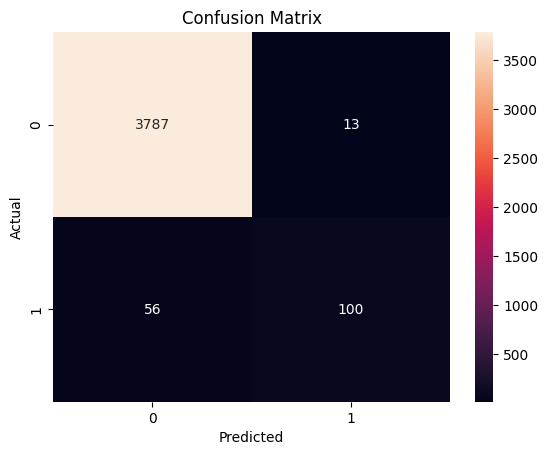

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")
plt.show()

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3800
           1       0.88      0.64      0.74       156

    accuracy                           0.98      3956
   macro avg       0.94      0.82      0.87      3956
weighted avg       0.98      0.98      0.98      3956



In [22]:
importance = model.feature_importances_
features = X.columns

import pandas as pd

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feat_df.head(10)

,Feature,Importance
2,tfidf_similarity,0.212861
4,Number of Issue,0.135002
12,issue_activity_ratio,0.074814
6,Number of Repository,0.068155
1,Number of following,0.056974
3,Number of Activity,0.052143
16,activity_per_day,0.046381
8,Number of Active day,0.045807
14,commit_per_repo,0.044316
11,Median Response Time,0.038207


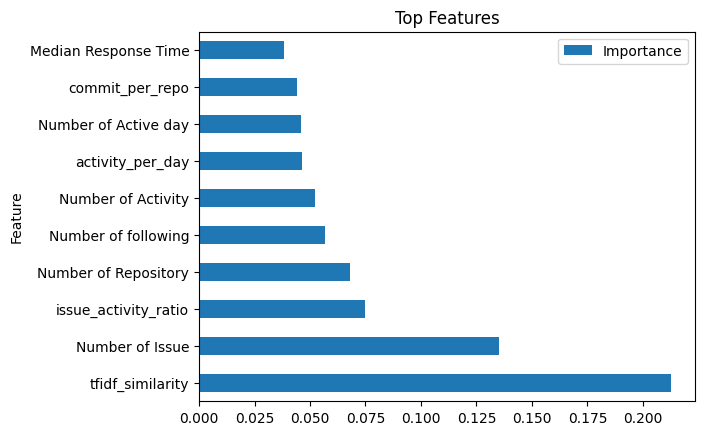

In [23]:
feat_df.head(10).plot(kind='barh', x='Feature', y='Importance')

plt.title("Top Features")
plt.savefig("feature_importance.png")
plt.show()